RFM Customer Segmentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("C:\\Users\\joel4\\Documents\\ecommerce-customer-analytics\\data\\online_retail_cleaned.csv")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,years,months,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,2010-12


In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [6]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [7]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True )

In [8]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [9]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


Recency Distribution

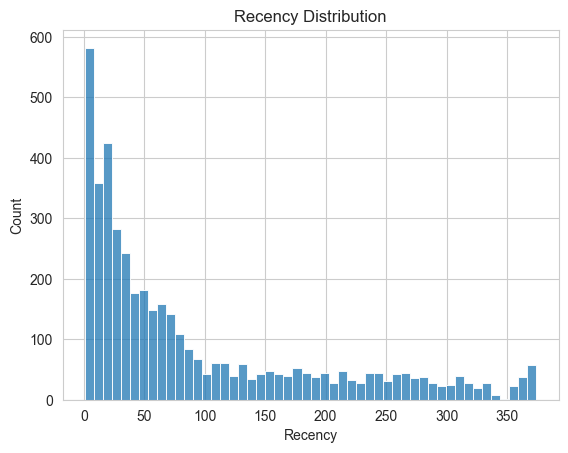

In [10]:
sns.histplot(rfm['Recency'], bins=50)
plt.title('Recency Distribution')
plt.show()

Frequency Distribution

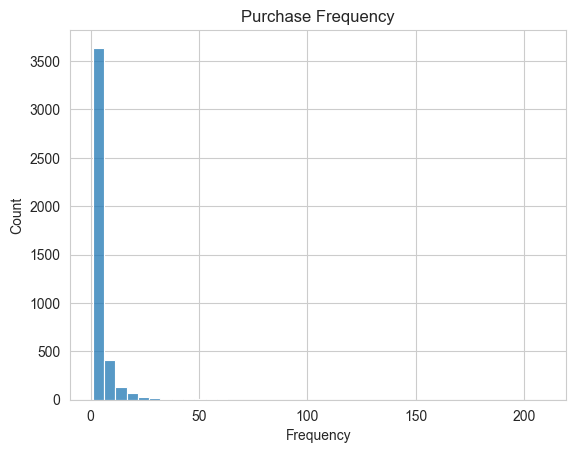

In [11]:
sns.histplot(rfm['Frequency'], bins=40)
plt.title('Purchase Frequency')
plt.show()

Monetary Distribution

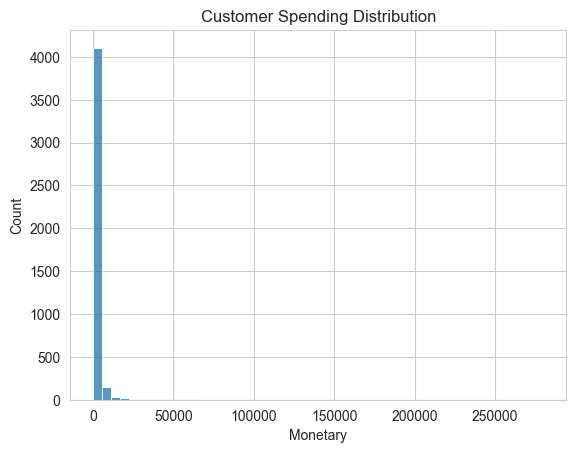

In [12]:
sns.histplot(rfm['Monetary'], bins=50)
plt.title("Customer Spending Distribution")
plt.show()

Recency Score

In [13]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

In [14]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

In [15]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

In [16]:
rfm['RFM_Score'] =(
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [17]:
def segment_customer(row):
    
    if row['R_score'] == 5 and row['F_score'] == 5 and row['F_score'] >= 4:
       return "Champions" 
    
    elif row['F_score'] >= 4:
        return "Loyal Customers"
    
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return "At Risk"
    
    elif row['R_score'] == 5 and row['F_score'] == 1:
        return "New Customers"
    
    return

In [18]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [19]:
rfm.head()


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,NaN
12347.0,2,7,4310.00,5,5,5,555,Champions
12348.0,75,4,1797.24,2,4,4,244,Loyal Customers
12349.0,19,1,1757.55,4,1,4,414,NaN
12350.0,310,1,334.40,1,1,2,112,NaN


In [20]:
rfm['Segment'].value_counts()

Segment
Loyal Customers    1296
Champions           439
At Risk             368
New Customers        42
Name: count, dtype: int64

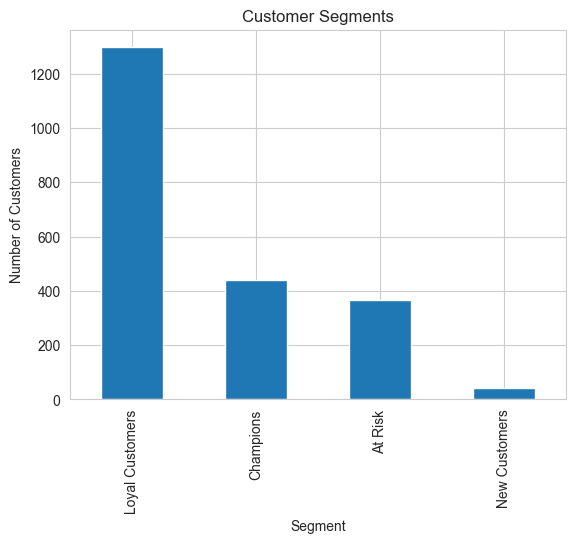

In [21]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.ylabel("Number of Customers")
plt.show()

In [22]:
segment_revenue = df.merge(
    rfm[['Segment']],
    left_on='CustomerID',
    right_index=True,
)

In [23]:
segment_revenue.groupby('Segment')['Revenue'].sum().sort_values(ascending=False)   

Segment
Champions          4040565.650
Loyal Customers    3096252.211
At Risk             367294.561
New Customers        16304.940
Name: Revenue, dtype: float64

In [24]:
rfm.to_pickle("rfm_data.pkl")